# Reprodução: *Sentiment Analysis of Twitter's Opinion on The Russia and Ukraine War Using BERT*

**Artigo:** Julianto, M. F., Malau, Y., & Hidayat, W. F. (2022). *Jurnal Riset Informatika*, 5(1). DOI: 10.34288/jri.v5i1.169

**Modalidade:** Reprodução experimental (mesma base de dados e configuração experimental).

| Hiperparâmetro | Valor |
|---|---|
| Modelo | `bert-base-multilingual-cased` |
| Epochs | 10 |
| Learning rate | 2e-5 |
| Batch size | 16 |
| Max sequence length | 160 |
| Otimizador | AdamW |
| Divisão | 90% treino / 5% val / 5% teste |


**Nota metodológica (rotulação):** o artigo original não documenta como os 17.951 tweets foram rotulados. A distribuição de classes reportada (≈17% negativo / 56% neutro / 27% positivo; support do teste = 154/500/244) é reproduzida com alta fidelidade pela polaridade do **TextBlob**, que adotamos como estratégia de rotulação.

In [1]:
!pip install -q transformers textblob seaborn

In [2]:
import ast, re, json, random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from textblob import TextBlob
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup

RANDOM_SEED = 42  # o artigo não fixa seed; fixamos para reprodutibilidade
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED); random.seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo:', device)

Dispositivo: cuda


## 1. Coleta do dataset

Dataset público do Kaggle: [Russia vs Ukraine Tweets](https://www.kaggle.com/datasets/vanamayaswanth/russia-vs-ukraine-tweets) (`War.csv`, 17.951 tweets de março/2022)

In [3]:
# Opção A: upload manual do War.csv
from google.colab import files
uploaded = files.upload()  # selecione o War.csv
CSV_PATH = 'War.csv'

Saving War.csv to War (1).csv


In [4]:
df = pd.read_csv(CSV_PATH).rename(columns={'a': 'date'})
print(df.shape)
df.head()

(17951, 2)


,date,tweets
0,2022-03-06 13:26:53+00:00,b'@Deese44 Russian aircraft recently dropped a...
1,2022-03-06 13:26:53+00:00,"b""RT @AnonOpsSE: Meanwhile in Russia, citizens..."
2,2022-03-06 13:26:52+00:00,b'@AnonOpsSE Someone k177 that Mf or he will f...
3,2022-03-06 13:26:51+00:00,b'RT @OffGuardian0: Do you see how totally the...
4,2022-03-06 13:26:50+00:00,b'@ROCORinCardiff The head of the Russian Orth...


## 2. Pré-processamento (Data Cleaning)

Os tweets estão armazenados como byte-strings (`b'...'`). Decodificamos para UTF-8 e, conforme o artigo, removemos símbolos, números, URLs e menções, mantendo apenas o texto.

In [5]:
def decode_tweet(raw):
    try:
        return ast.literal_eval(raw).decode('utf-8', errors='ignore')
    except (ValueError, SyntaxError):
        return str(raw)

def clean_text(text):
    text = re.sub(r'^RT\s+', '', text)            # marcador de retweet
    text = re.sub(r'http\S+|www\.\S+', '', text) # URLs
    text = re.sub(r'@\w+', '', text)              # menções
    text = re.sub(r'#', '', text)                  # mantém a palavra da hashtag
    text = re.sub(r'[^A-Za-zÀ-ÿ\s]', ' ', text)   # símbolos e números
    return re.sub(r'\s+', ' ', text).strip()

df['text_raw'] = df['tweets'].apply(decode_tweet)
df['text'] = df['text_raw'].apply(clean_text)
df = df[df['text'].str.len() > 0].reset_index(drop=True)
print(f'{len(df)} tweets após a limpeza')
df[['text_raw', 'text']].head()

17870 tweets após a limpeza


,text_raw,text
0,@Deese44 Russian aircraft recently dropped an ...,Russian aircraft recently dropped an RBC clust...
1,"RT @AnonOpsSE: Meanwhile in Russia, citizens d...",Meanwhile in Russia citizens doesn t know what...
2,@AnonOpsSE Someone k177 that Mf or he will f03...,Someone k that Mf or he will f us ALL StandWit...
3,RT @OffGuardian0: Do you see how totally the a...,Do you see how totally the anti Great Reset mo...
4,@ROCORinCardiff The head of the Russian Orthod...,The head of the Russian Orthodox Church patria...


## 3. Rotulação do dataset

Rotulação automática pela polaridade do TextBlob: `>0` positivo (2), `<0` negativo (0), `=0` neutro (1) — reproduzindo a distribuição reportada no artigo (Figuras 9 e 10).

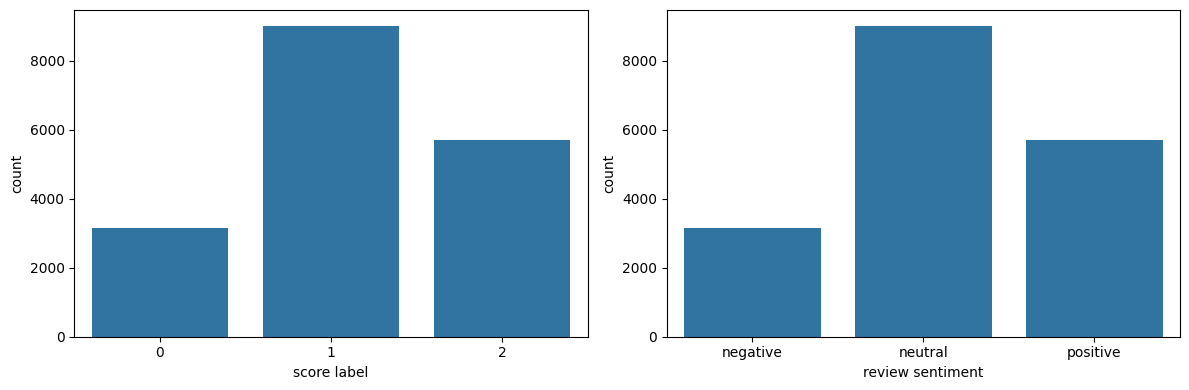

sentiment
neutral     9022
positive    5701
negative    3147
Name: count, dtype: int64


In [6]:
LABEL_NAMES = ['negative', 'neutral', 'positive']

def label_polarity(text):
    p = TextBlob(text).sentiment.polarity
    return 2 if p > 0 else (0 if p < 0 else 1)

df['label'] = df['text'].apply(label_polarity)
df['sentiment'] = df['label'].map(dict(enumerate(LABEL_NAMES)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='label', data=df, ax=axes[0]); axes[0].set_xlabel('score label')
sns.countplot(x='sentiment', data=df, order=LABEL_NAMES, ax=axes[1])
axes[1].set_xlabel('review sentiment')
plt.tight_layout(); plt.show()
print(df['sentiment'].value_counts())

## 4. Tokenização

Tokenizador WordPiece do `bert-base-multilingual-cased`, com tokens especiais `[CLS]`/`[SEP]`. A escolha do comprimento de sequência segue a análise de distribuição do artigo (Figura 15), resultando em `MAX_LEN = 160`.

In [7]:
PRE_TRAINED_MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

# Exemplo de tokenização (Figura 13 do artigo)
sample = 'stop this war'
tokens = tokenizer.tokenize(sample)
print('Sentence:', sample)
print('Tokens:', tokens)
print('Token IDs:', tokenizer.convert_tokens_to_ids(tokens))

# Tokens especiais (Figura 14)
print((tokenizer.sep_token, tokenizer.sep_token_id))
print((tokenizer.cls_token, tokenizer.cls_token_id))
print((tokenizer.pad_token, tokenizer.pad_token_id))
print((tokenizer.unk_token, tokenizer.unk_token_id))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Sentence: stop this war
Tokens: ['stop', 'this', 'war']
Token IDs: [20517, 10531, 10338]
('[SEP]', 102)
('[CLS]', 101)
('[PAD]', 0)
('[UNK]', 100)


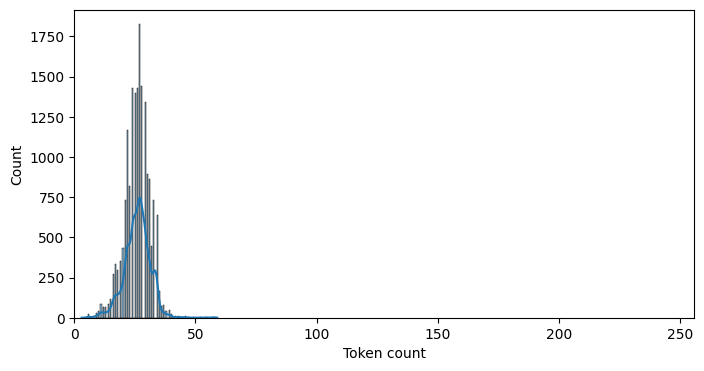

In [8]:
# Distribuição do comprimento de tokens (Figura 15)
token_lens = [len(tokenizer.encode(t, max_length=512, truncation=True)) for t in df['text']]
plt.figure(figsize=(8, 4))
sns.histplot(token_lens, kde=True)
plt.xlim(0, 256); plt.xlabel('Token count'); plt.show()

MAX_LEN = 160

## 5. Divisão do dataset e DataLoaders

90% treino / 5% validação / 5% teste (Figura 18 do artigo: 16.155 / 898 / 898).

In [9]:
df_train, df_rest = train_test_split(df, test_size=0.1, random_state=RANDOM_SEED, stratify=df['label'])
df_val, df_test = train_test_split(df_rest, test_size=0.5, random_state=RANDOM_SEED, stratify=df_rest['label'])
print(df_train.shape, df_val.shape, df_test.shape)

(16083, 6) (893, 6) (894, 6)


In [12]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts, self.labels = list(texts), list(labels)
        self.tokenizer, self.max_len = tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]), add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True,
            return_attention_mask=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].flatten(),
                'attention_mask': enc['attention_mask'].flatten(),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

def create_data_loader(d, shuffle=False):
    ds = TweetDataset(d['text'].values, d['label'].values, tokenizer)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2)

BATCH_SIZE = 16

train_loader = create_data_loader(df_train, shuffle=True)
val_loader = create_data_loader(df_val)
test_loader = create_data_loader(df_test)

## 6. Implementação do BERT

Vetor do token `[CLS]` (768 dim) → Dropout → camada Linear → 3 classes (softmax via CrossEntropyLoss).

In [13]:
class SentimentClassifier(nn.Module):
    def __init__(self, n_classes=3, dropout=0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        self.drop = nn.Dropout(p=dropout)
        self.out = nn.Linear(self.bert.config.hidden_size, n_classes)
    def forward(self, input_ids, attention_mask):
        pooled = self.bert(input_ids=input_ids, attention_mask=attention_mask).pooler_output
        return self.out(self.drop(pooled))

model = SentimentClassifier().to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 7. Treinamento (fine-tuning)

Hiperparâmetros do artigo: 10 epochs, learning rate 2e-5, batch 16, AdamW.

In [14]:
EPOCHS = 10
optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
loss_fn = nn.CrossEntropyLoss().to(device)
scaler = torch.amp.GradScaler('cuda')

def run_epoch(model, loader, training=False):
    model.train() if training else model.eval()
    losses, correct, total = [], 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            with torch.autocast('cuda', dtype=torch.float16):
                outputs = model(input_ids, attention_mask)
                loss = loss_fn(outputs, labels)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
            losses.append(loss.item())
            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()
    return correct / total, np.mean(losses)

In [15]:
history = defaultdict(list)
best_acc = 0

for epoch in range(1, EPOCHS + 1):
    print(f'Epoch {epoch}/{EPOCHS}'); print('-' * 30)
    train_acc, train_loss = run_epoch(model, train_loader, training=True)
    val_acc, val_loss = run_epoch(model, val_loader)
    print(f'Train loss {train_loss:.4f} accuracy {train_acc:.4f}')
    print(f'Val   loss {val_loss:.4f} accuracy {val_acc:.4f}\n')
    history['train_acc'].append(train_acc); history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc); history['val_loss'].append(val_loss)
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'best_model.bin')

with open('history.json', 'w') as f:
    json.dump(history, f, indent=2)
print('Melhor acurácia de validação:', round(best_acc, 4))

Epoch 1/10
------------------------------


/tmp/ipykernel_11534/431760877.py:29: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Train loss 0.4471 accuracy 0.8313
Val   loss 0.2065 accuracy 0.9518

Epoch 2/10
------------------------------
Train loss 0.1700 accuracy 0.9576
Val   loss 0.1409 accuracy 0.9698

Epoch 3/10
------------------------------
Train loss 0.0966 accuracy 0.9781
Val   loss 0.0916 accuracy 0.9798

Epoch 4/10
------------------------------
Train loss 0.0516 accuracy 0.9886
Val   loss 0.1028 accuracy 0.9843

Epoch 5/10
------------------------------
Train loss 0.0326 accuracy 0.9939
Val   loss 0.1636 accuracy 0.9731

Epoch 6/10
------------------------------
Train loss 0.0179 accuracy 0.9965
Val   loss 0.1194 accuracy 0.9832

Epoch 7/10
------------------------------
Train loss 0.0121 accuracy 0.9979
Val   loss 0.1388 accuracy 0.9832

Epoch 8/10
------------------------------
Train loss 0.0094 accuracy 0.9983
Val   loss 0.1249 accuracy 0.9843

Epoch 9/10
------------------------------
Train loss 0.0059 accuracy 0.9990
Val   loss 0.1352 accuracy 0.9843

Epoch 10/10
------------------------------


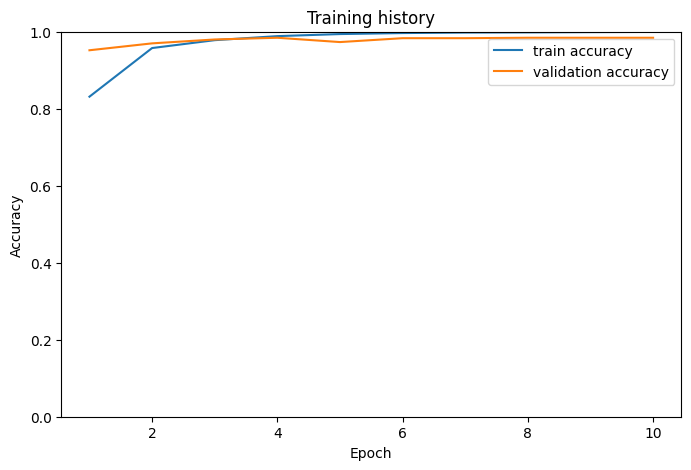

In [16]:
# Curva de treinamento (Figura 17 do artigo)
epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history['train_acc'], label='train accuracy')
plt.plot(epochs_range, history['val_acc'], label='validation accuracy')
plt.title('Training history'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.ylim(0, 1); plt.legend(); plt.savefig('training_history.png', dpi=150); plt.show()

## 8. Avaliação

Acurácia, precision/recall/F1 por classe (Figura 20) e matriz de confusão (Figura 21) no conjunto de teste, usando o melhor modelo salvo.

In [17]:
model.load_state_dict(torch.load('best_model.bin'))
model.eval()

preds, labels = [], []
with torch.no_grad():
    for batch in test_loader:
        outputs = model(batch['input_ids'].to(device), batch['attention_mask'].to(device))
        preds.extend(outputs.argmax(1).cpu().tolist())
        labels.extend(batch['label'].tolist())

test_acc = accuracy_score(labels, preds)
print(f'Test accuracy: {test_acc:.4f}\n')
report = classification_report(labels, preds, target_names=LABEL_NAMES)
print(report)
with open('classification_report.txt', 'w') as f:
    f.write(f'Test accuracy: {test_acc:.4f}\n\n{report}')

Test accuracy: 0.9620

              precision    recall  f1-score   support

    negative       0.91      0.92      0.92       158
     neutral       0.97      0.98      0.98       451
    positive       0.98      0.95      0.96       285

    accuracy                           0.96       894
   macro avg       0.95      0.95      0.95       894
weighted avg       0.96      0.96      0.96       894



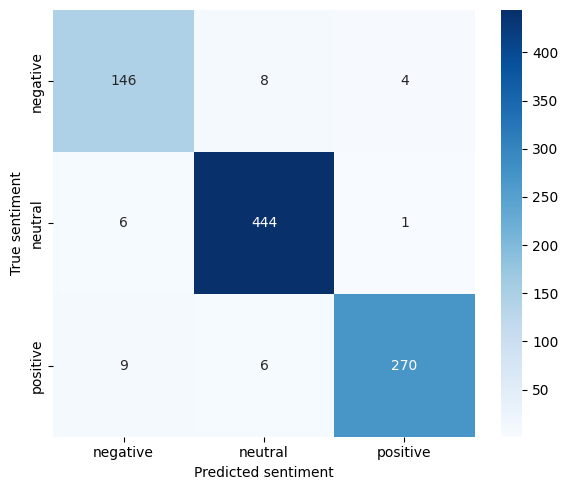

In [18]:
cm = confusion_matrix(labels, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.xlabel('Predicted sentiment'); plt.ylabel('True sentiment')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

In [ ]:
from google.colab import files
for f in ['history.json', 'classification_report.txt', 'training_history.png', 'confusion_matrix.png']:
    files.download(f)